# Hands-On Pertemuan 9: Spark SQL

## Tujuan:
- Mengasah keterampilan analisis data menggunakan Spark SQL.
- Melakukan lebih banyak latihan SQL yang mengarah ke skenario dunia nyata.
- Mempersiapkan mahasiswa untuk menggunakan Spark SQL dalam proyek besar.


### 1. Refresher: Basic SQL Operations in Spark SQL
- **Tugas 1**: Ulangi pemahaman Anda tentang SQL dasar dengan menjalankan queries sederhana pada dataset di Spark SQL.


In [3]:
from pyspark.sql import SparkSession 

spark = SparkSession.builder.appName('Pertemuan_9').getOrCreate()

data = [
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
]
columns = ['Name', 'Age', 'Gender', 'Salary', 'DeptId']
df = spark.createDataFrame(data, schema=columns)
df.createOrReplaceTempView('employees')
spark.sql('SELECT * FROM employees').show()
spark.sql('SELECT Name, Age FROM employees WHERE Salary > 3000').show()
spark.sql('SELECT AVG(Salary) FROM employees').show()


24/10/23 08:20:09 WARN Utils: Your hostname, DEDSEC resolves to a loopback address: 127.0.1.1; using 192.168.137.203 instead (on interface wlp2s0)
24/10/23 08:20:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/10/23 08:20:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+-----+---+------+------+------+
| Name|Age|Gender|Salary|DeptId|
+-----+---+------+------+------+
|James| 34|     M|  3000|     1|
| Anna| 28|     F|  4100|     2|
|  Lee| 23|     M|  2700|     1|
+-----+---+------+------+------+

+----+---+
|Name|Age|
+----+---+
|Anna| 28|
+----+---+



+------------------+
|       avg(Salary)|
+------------------+
|3266.6666666666665|
+------------------+



### 2. Advanced Queries for Data Analysis
Gunakan queries lebih kompleks, melibatkan grouping, filtering, dan subqueries.
- **Tugas 2**: Buat SQL query yang menghitung total gaji berdasarkan jenis kelamin dan usia.


In [4]:
spark.sql('''
SELECT Gender, SUM(Salary) as TotalSalary, Age
FROM employees
GROUP BY Gender, Age
ORDER BY Age
''').show()

spark.sql('SELECT DeptId, AVG(Salary) AS AvgSalary FROM Employees GROUP BY DeptId').show()

spark.sql('''
WITH AvgSalaryByGender AS (
    SELECT Gender, AVG(Salary) AS AvgSalary
    FROM Employees
    GROUP BY Gender
)
SELECT e.Name, e.Gender, e.Salary
FROM Employees e
JOIN AvgSalaryByGender a
ON e.Gender = a.Gender
WHERE e.Salary > a.AvgSalary
''').show()

from pyspark.sql.window import Window
from pyspark.sql import functions as F


df.withColumn("Rank", F.dense_rank().over(Window.partitionBy("DeptId").orderBy(F.desc("Salary")))).show()


+------+-----------+---+
|Gender|TotalSalary|Age|
+------+-----------+---+
|     M|       2700| 23|
|     F|       4100| 28|
|     M|       3000| 34|
+------+-----------+---+

+------+---------+
|DeptId|AvgSalary|
+------+---------+
|     1|   2850.0|
|     2|   4100.0|
+------+---------+



+-----+------+------+
| Name|Gender|Salary|
+-----+------+------+
|James|     M|  3000|
+-----+------+------+

+-----+---+------+------+------+----+
| Name|Age|Gender|Salary|DeptId|Rank|
+-----+---+------+------+------+----+
|James| 34|     M|  3000|     1|   1|
|  Lee| 23|     M|  2700|     1|   2|
| Anna| 28|     F|  4100|     2|   1|
+-----+---+------+------+------+----+



- **Tugas Tambahan 2**: 
1. Cari rata-rata gaji per departemen.
2. Temukan karyawan yang memiliki gaji di atas rata-rata untuk gender masing-masing.
3. Buat ranking karyawan berdasarkan gaji dalam departemen mereka.


### 3. Penggunaan Window Functions dan Subqueries
Latihan penggunaan window functions untuk menemukan karyawan dengan gaji tertinggi dan urutannya berdasarkan kelompok usia.
- **Tugas 3**: Terapkan window functions untuk menemukan top 3 karyawan dalam kelompok usia tertentu.


In [5]:
spark.sql('''
SELECT Name, Age, Salary, ROW_NUMBER() OVER (PARTITION BY Age ORDER BY Salary DESC) as rank
FROM employees
''').show()


+-----+---+------+----+
| Name|Age|Salary|rank|
+-----+---+------+----+
|  Lee| 23|  2700|   1|
| Anna| 28|  4100|   1|
|James| 34|  3000|   1|
+-----+---+------+----+



### 4. Advanced Spark SQL Queries
Menjelajahi queries yang lebih kompleks yang melibatkan multiple joins, subqueries, dan window functions.
- **Tugas 4**: Demonstrasi penggunaan multi-level joins dan subqueries untuk analisis data yang mendalam.


In [6]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Pertemuan9').getOrCreate()

# Data setup for complex SQL queries
employees = spark.createDataFrame([
    ('James', 34, 'M', 3000, 1),
    ('Anna', 28, 'F', 4100, 2),
    ('Lee', 23, 'M', 2700, 1)
], ['Name', 'Age', 'Gender', 'Salary', 'DeptId'])
departments = spark.createDataFrame([
    (1, 'HR'),
    (2, 'Marketing')
], ['DeptId', 'DeptName'])
projects = spark.createDataFrame([
    (1, 'Project A'),
    (2, 'Project B')
], ['DeptId', 'ProjectName'])
employees.createOrReplaceTempView('employees')
departments.createOrReplaceTempView('departments')
projects.createOrReplaceTempView('projects')

# Complex SQL query involving multiple joins and subqueries
spark.sql('''
SELECT e.Name, e.Age, d.DeptName, p.ProjectName
FROM employees e
JOIN departments d ON e.DeptId = d.DeptId
JOIN projects p ON e.DeptId = p.DeptId
''').show()


24/10/23 08:20:40 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


+-----+---+---------+-----------+
| Name|Age| DeptName|ProjectName|
+-----+---+---------+-----------+
|  Lee| 23|       HR|  Project A|
|James| 34|       HR|  Project A|
| Anna| 28|Marketing|  Project B|
+-----+---+---------+-----------+



Latihan mandiri untuk memperkuat pemahaman tentang Spark SQL dalam analisis data terdistribusi.
- **Tugas 5**: Tuliskan query SQL untuk menemukan rata-rata gaji per departemen dan rangking setiap karyawan dalam departemen berdasarkan gaji.
- **Tugas 6**: Gunakan window functions untuk menentukan tren gaji berdasarkan usia di setiap departemen.


### 5. Advanced Data Analysis and Visualization
Penerapan teknik analisis data yang lebih canggih dan visualisasi menggunakan PySpark dan matplotlib.
- **Tugas 7**: Lakukan analisis tren gaji menggunakan Spark SQL dan visualisasikan hasilnya.


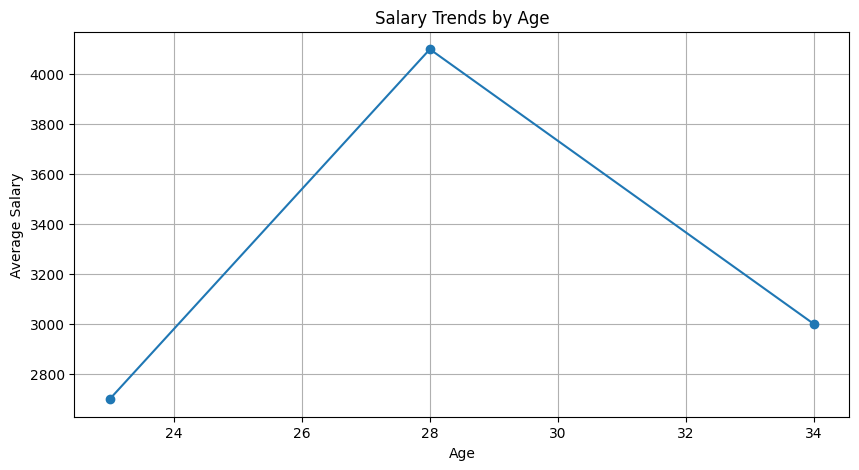

In [9]:

import matplotlib.pyplot as plt
import pandas as pd

# Advanced data analysis with visualization
salary_trends = spark.sql('''
SELECT Age, AVG(Salary) AS AverageSalary
FROM employees
GROUP BY Age
ORDER BY Age
''').toPandas()

# Visualization of salary trends
plt.figure(figsize=(10, 5))
plt.plot(salary_trends['Age'], salary_trends['AverageSalary'], marker='o')
plt.xlabel('Age')
plt.ylabel('Average Salary')
plt.title('Salary Trends by Age')
plt.grid(True)
plt.show()




### 6. Homework
- **Tugas 1**: Gunakan Spark SQL untuk mencari total gaji dan jumlah karyawan per departemen. Buat visualisasi perbandingan antar departemen.
- **Tugas 2**: Temukan karyawan dengan gaji di atas rata-rata dalam setiap kelompok usia dan visualisasikan data ini dalam bentuk grafik batang atau pie chart.
- **Tugas 3**: Buat dataset yang lebih besar (misalnya, 100+ baris) dan lakukan analisis mendalam menggunakan SQL functions seperti `SUM()`, `AVG()`, `COUNT()`, serta `JOIN` antar tabel.


+---------+--------------+---------+
| DeptName|JumlahKaryawan|TotalGaji|
+---------+--------------+---------+
|       HR|             2|     5700|
|Marketing|             1|     4100|
+---------+--------------+---------+



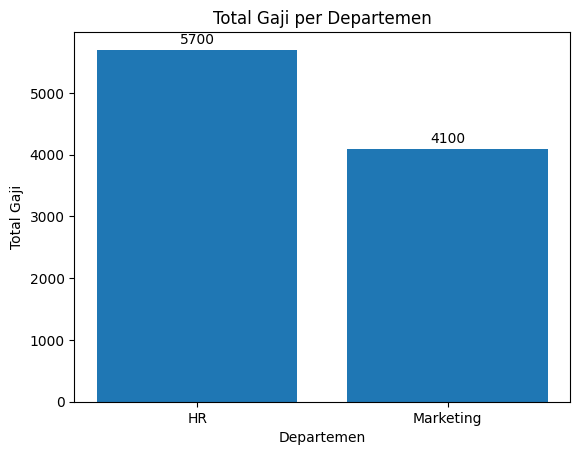

In [17]:
# Register DataFrames as SQL temporary views
employees.createOrReplaceTempView("employees")
departments.createOrReplaceTempView("departments")

# SQL query untuk mencari total gaji dan jumlah karyawan per departemen
result_tugas1 = spark.sql("""
    SELECT d.DeptName, COUNT(e.Name) as JumlahKaryawan, SUM(e.Salary) as TotalGaji
    FROM employees e
    JOIN departments d ON e.DeptId = d.DeptId
    GROUP BY d.DeptName
""")

# Menampilkan hasil query
result_tugas1.show()

# Mengambil data untuk visualisasi
result_pd = result_tugas1.toPandas()

# Visualisasi dengan bar chart
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.bar(result_pd['DeptName'], result_pd['TotalGaji'], label='Total Gaji')
ax.set_xlabel('Departemen')
ax.set_ylabel('Total Gaji')
ax.set_title('Total Gaji per Departemen')

# Menambahkan angka di atas bar
for i in range(len(result_pd)):
    ax.text(i, result_pd['TotalGaji'][i] + 100, result_pd['TotalGaji'][i], ha='center')

plt.show()


+----+---+------+---------+--------+
|Name|Age|Salary|AvgSalary|AgeGroup|
+----+---+------+---------+--------+
|Anna| 28|  4100|   3400.0|   20-30|
+----+---+------+---------+--------+



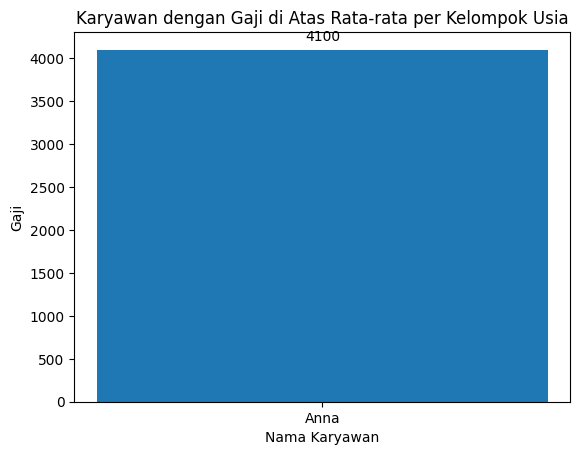

In [18]:
# SQL query untuk menghitung rata-rata gaji per kelompok usia
result_tugas2 = spark.sql("""
    SELECT 
        CASE 
            WHEN Age BETWEEN 20 AND 30 THEN '20-30'
            WHEN Age BETWEEN 31 AND 40 THEN '31-40'
        END as AgeGroup, AVG(Salary) as AvgSalary
    FROM employees
    GROUP BY AgeGroup
""")
result_tugas2.createOrReplaceTempView("avg_salary_by_age")

# SQL query untuk mencari karyawan dengan gaji di atas rata-rata per kelompok usia
above_avg_salary = spark.sql("""
    SELECT e.Name, e.Age, e.Salary, avg_s.AvgSalary, avg_s.AgeGroup
    FROM employees e
    JOIN avg_salary_by_age avg_s 
    ON (CASE 
            WHEN e.Age BETWEEN 20 AND 30 THEN '20-30'
            WHEN e.Age BETWEEN 31 AND 40 THEN '31-40'
        END) = avg_s.AgeGroup
    WHERE e.Salary > avg_s.AvgSalary
""")

# Menampilkan hasil
above_avg_salary.show()

# Visualisasi dengan bar chart
result_pd = above_avg_salary.toPandas()

fig, ax = plt.subplots()
ax.bar(result_pd['Name'], result_pd['Salary'], label='Gaji')
ax.set_xlabel('Nama Karyawan')
ax.set_ylabel('Gaji')
ax.set_title('Karyawan dengan Gaji di Atas Rata-rata per Kelompok Usia')

# Menambahkan angka di atas bar
for i in range(len(result_pd)):
    ax.text(i, result_pd['Salary'][i] + 100, result_pd['Salary'][i], ha='center')

plt.show()


+---------+--------------+------------+---------+
| DeptName|JumlahKaryawan|RataRataGaji|TotalGaji|
+---------+--------------+------------+---------+
|       HR|           100|      2850.0|   285000|
|Marketing|            50|      4100.0|   205000|
+---------+--------------+------------+---------+



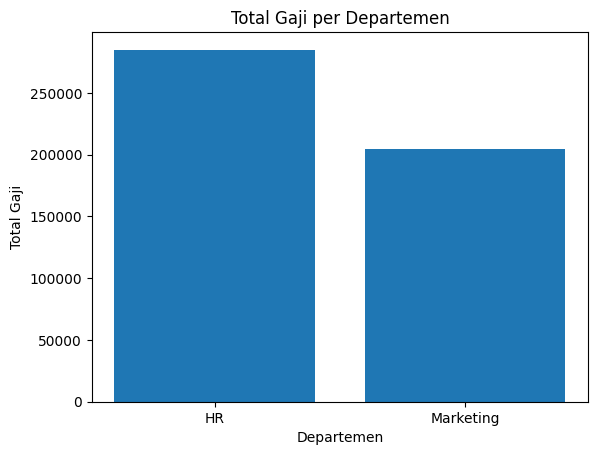

In [19]:
from pyspark.sql import Row

# Membuat data lebih besar untuk employees
data_employees = [
    Row('James', 34, 'M', 3000, 1),
    Row('Anna', 28, 'F', 4100, 2),
    Row('Lee', 23, 'M', 2700, 1),
    # Tambah lebih banyak baris di sini (misalnya 100+ baris)
    # Contoh baris tambahan
] * 50  # Melipatgandakan jumlah data

# Convert to DataFrame
employees_large = spark.createDataFrame(data_employees, ['Name', 'Age', 'Gender', 'Salary', 'DeptId'])

# Register dataframe sebagai SQL view
employees_large.createOrReplaceTempView("employees_large")

# Contoh analisis SQL: mencari total karyawan, rata-rata gaji, dan total gaji per departemen
result_tugas3 = spark.sql("""
    SELECT d.DeptName, COUNT(e.Name) as JumlahKaryawan, AVG(e.Salary) as RataRataGaji, SUM(e.Salary) as TotalGaji
    FROM employees_large e
    JOIN departments d ON e.DeptId = d.DeptId
    GROUP BY d.DeptName
""")

# Menampilkan hasil query
result_tugas3.show()

# Visualisasi hasil
result_pd = result_tugas3.toPandas()

fig, ax = plt.subplots()
ax.bar(result_pd['DeptName'], result_pd['TotalGaji'], label='Total Gaji')
ax.set_xlabel('Departemen')
ax.set_ylabel('Total Gaji')
ax.set_title('Total Gaji per Departemen')

plt.show()
